# Statistics and Data Analysis with Python

Statistics and data visualization go hand in hand. In this workshop, we'll walk through fundamental statistical concepts, implement them in Python, and bring them to life with visualizations.

We'll work with real stock market data using **yfinance**, a library that fetches historical and real-time market data from Yahoo Finance for any publicly traded company or currency — free, fast, and convenient.


In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
import random
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

import yfinance as yf

## 1. Exploratory Data Analysis and Descriptive Statistics

### 1.1 Fetching and Preparing the Data

Let's start by pulling two years of Microsoft stock data. Microsoft trades under the ticker `MSFT`, but feel free to swap it for any ticker you like after working through the workshop. The `.download()` method in `yfinance` returns a pandas DataFrame containing the requested data.


In [2]:
ticker=['MSFT']
data = yf.download(ticker, period='2y')
data.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2024-02-28,401.556610,403.112712,399.192896,402.009648,13183100
2024-02-29,407.387146,407.938678,399.783846,402.462729,31947300
2024-03-01,409.219025,409.583427,404.668868,405.052957,17823400
2024-03-04,408.647827,411.041087,406.087124,407.190189,17596000
2024-03-05,396.563202,407.987853,394.583607,407.702228,26919200


The DataFrame returned by `.download()` uses a multi-level column index and a date index. Each row represents a single trading day and includes the closing price, the daily high and low, the opening price, and the trading volume.

We'll create a cleaner DataFrame that gives the date its own column and retains only the closing price. We'll also compute a **daily return** column — the percentage change in price from the previous trading day.


In [3]:
df=pd.DataFrame(columns=['date','MSFT_close', 'MSFT_return'])
#list to store the previous day price - this will help with calculating the daily returns
msft_prev=[]
#we'll store the daily returns in this list. We'll say the first day in the dataset will have a return of 0%.
msft_return=[0]

for index, row in data.iterrows():
    if len(msft_prev)>0:
        #subtract current day price from previous day price and divide by previous day price to get proportion of change
        msft_chg=(row['Close']['MSFT']-msft_prev[-1])/msft_prev[-1]
        #convert proportion to percentage and append the daily return to the msft_return list
        msft_return.append(msft_chg*100)
        #append current day price to previous day price list for use "tomorrow"
        msft_prev.append(row['Close']['MSFT'])
    else:
        msft_prev.append(row['Close']['MSFT'])
    #add a new row to our empty dataframe - we'll need the date (which is the index), the closing price, and the daily return.
    df.loc[len(df)]=[index, row['Close']['MSFT'], msft_return[-1]]
df.head()

,date,MSFT_close,MSFT_return
0,2024-02-28,401.556610,0.000000
1,2024-02-29,407.387146,1.451984
2,2024-03-01,409.219025,0.449665
3,2024-03-04,408.647827,-0.139582
4,2024-03-05,396.563202,-2.957222


### 1.2 Building a Reusable Data Function

Rather than repeating this logic every time we need fresh data, let's wrap it in a reusable function. It accepts a list of tickers and a time period, and returns a clean DataFrame with the closing price and daily return for each ticker.


In [4]:
def get_tickers(tickers, period):
    #make call to yfinance
    data = yf.download(tickers, period=period)
    #create new dataframe with return data
    cols=['date']
    for t in tickers:
        cols.append(t+'_close')
        cols.append(t+'_return')
    df=pd.DataFrame(columns=cols)
    #create price dictionary. ticker will be key, values will be another dictionary with prices and returns
    d_price={t:{'price':[], 'return':[0]} for t in tickers}
    for index, row in data.iterrows():
        irow=[index]
        for t in tickers:
            if len(d_price[t]['price'])>0:
                #subtract current day price from previous day price and divide by previous day price to get proportion of change
                chg=(row['Close'][t]-d_price[t]['price'][-1])/d_price[t]['price'][-1]
                #convert proportion to percentage and append the daily return to the msft_return list
                d_price[t]['return'].append(chg*100)
                #append current day price to previous day price list for use "tomorrow"
                d_price[t]['price'].append(row['Close'][t])
            else:
                d_price[t]['price'].append(row['Close'][t])
            irow.append(row['Close'][t])
            irow.append(d_price[t]['return'][-1])
        #add a new row to our empty dataframe - we'll need the date (which is the index), the closing price, and the daily return.
        df.loc[len(df)]=irow
    return df

In [5]:
#let's try it out - we'll just use the microsoft ticker for now. Later we'llpull in multiple tickers.
my_tickers=['MSFT']

df=get_tickers(tickers=my_tickers, period='2y')
df.head()

[*********************100%***********************]  1 of 1 completed


,date,MSFT_close,MSFT_return
0,2024-02-28,401.556641,0.000000
1,2024-02-29,407.387146,1.451976
2,2024-03-01,409.218994,0.449658
3,2024-03-04,408.647797,-0.139582
4,2024-03-05,396.563263,-2.957200


### 1.3 Exploring the Price Distribution

When starting any data project, the first step is exploration. We'll compute high-level descriptive statistics — mean, median, standard deviation — and create quick visualizations to understand the shape and spread of the data. Let's begin by examining the distribution of the closing price.


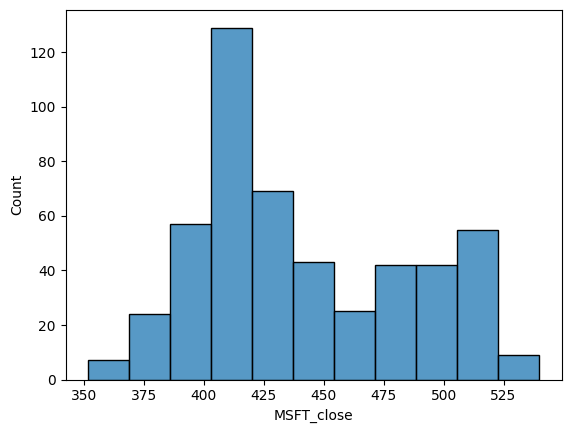

In [6]:
sns.histplot(data=df, x='MSFT_close');

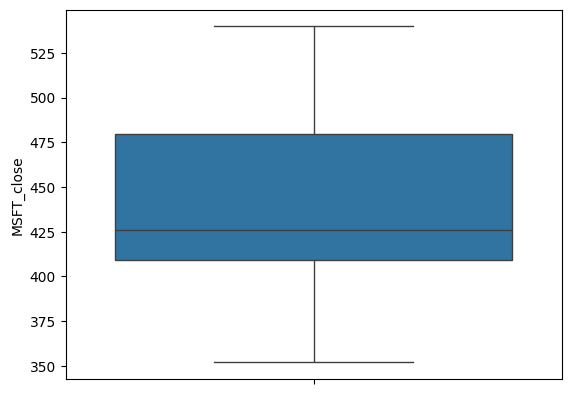

In [7]:
sns.boxplot(y=df.MSFT_close);

In [8]:
mean_price=df.MSFT_close.mean()
median_price=df.MSFT_close.median()

print(f'Mean Price: ${mean_price:,.2f}') 
print(f'Median Price: ${median_price:,.2f}') 

Mean Price: $441.40
Median Price: $426.08


### 1.4 Exploring Daily Returns

Now let's look at the distribution of daily returns. Returns tend to be more informative than raw price when comparing performance across securities, since they normalize for differences in price scale.


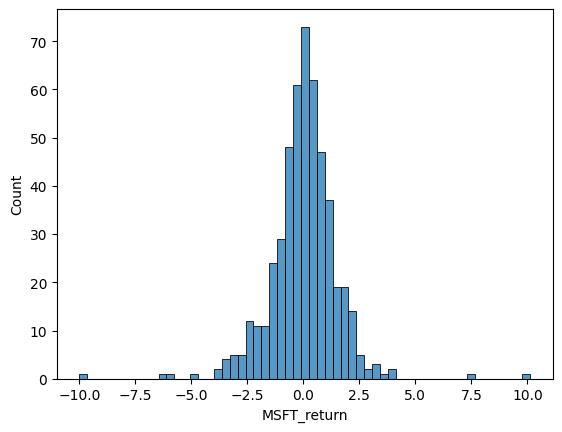

In [9]:
sns.histplot(data=df, x='MSFT_return');

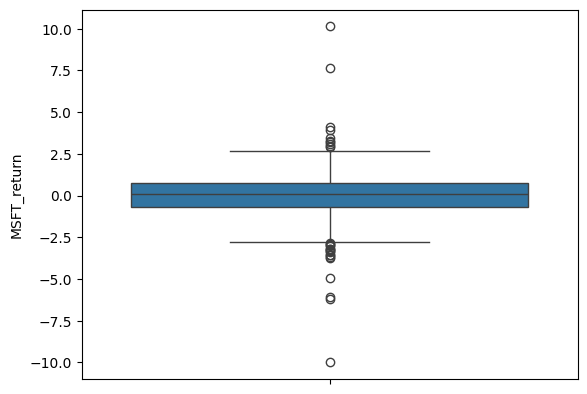

In [10]:
sns.boxplot(y=df.MSFT_return);

Let's compute the mean and standard deviation of the daily returns. The standard deviation is a key measure of **volatility** — how much the stock price fluctuates from day to day.


In [11]:
mean_return=df.MSFT_return.mean()
sd_return=df.MSFT_return.std()

print(f'Mean Daily Return: {mean_return:,.2f}%') 
print(f'Standard Deviation: {sd_return:,.2f}%') 

Mean Daily Return: 0.01%
Standard Deviation: 1.52%


### 1.5 Publication-Quality Visualizations

The quick plots above are great for exploration, but when we want to share results with an audience, we need more control over layout and style. The standard approach is to define a figure and axes object using `plt.subplots()`, which provides:

- Control over the figure size
- The ability to arrange multiple plots within a single figure
- Direct access to axis-level formatting

We'll use this pattern for all polished visualizations going forward. Here, we'll recreate the returns histogram with reference lines at the mean and ±1 standard deviation to illustrate volatility.


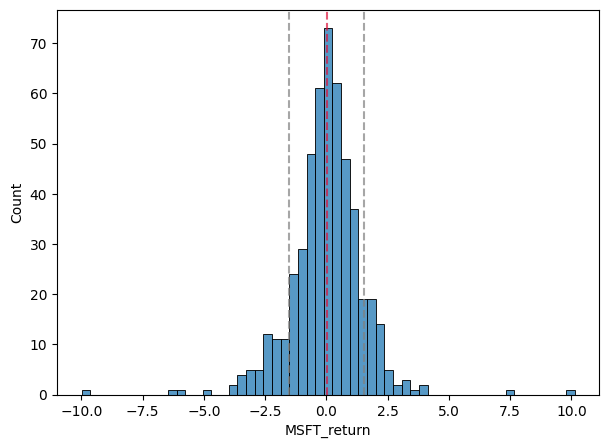

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(data=df, x='MSFT_return', ax=ax)
#let's plot lines at the mean return and the mean +/- a standard deviation to get a sense of how volitile the stock has been
plt.axvline(x=mean_return, color='crimson', linestyle='--', alpha=0.7)
plt.axvline(x=mean_return-sd_return, color='grey', linestyle='--', alpha=0.7)
plt.axvline(x=mean_return+sd_return, color='grey', linestyle='--', alpha=0.7);

### 1.6 Price Trends Over Time

A histogram tells us about the distribution of prices but not how they evolved over time. A line plot gives us that temporal context and can help explain the extreme values we observed in the return distribution.


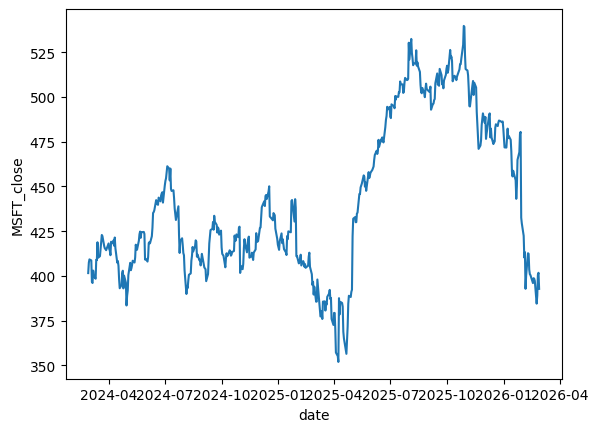

In [13]:
sns.lineplot(data=df, x='date', y='MSFT_close');

There are some notable price movements in this data. Let's add **moving averages** to identify underlying trends that can be obscured by day-to-day volatility. The `.rolling()` method in pandas makes this straightforward — we'll compute both a 30-day and a 50-day moving average.


In [14]:
df['30_ma']=df.MSFT_close.rolling(30).mean()
df['50_ma']=df.MSFT_close.rolling(50).mean()
df

,date,MSFT_close,MSFT_return,30_ma,50_ma
0,2024-02-28,401.556641,0.000000,NaN,NaN
1,2024-02-29,407.387146,1.451976,NaN,NaN
2,2024-03-01,409.218994,0.449658,NaN,NaN
3,2024-03-04,408.647797,-0.139582,NaN,NaN
4,2024-03-05,396.563263,-2.957200,NaN,NaN
...,...,...,...,...,...
497,2026-02-23,384.470001,-3.212247,431.426078,451.004478
498,2026-02-24,389.000000,1.178245,428.453126,449.235074
499,2026-02-25,400.600006,2.982007,425.936682,447.599694
500,2026-02-26,401.720001,0.279579,423.674076,446.085288


Now let's plot the price data and the moving averages on a single figure and make it presentation-ready.

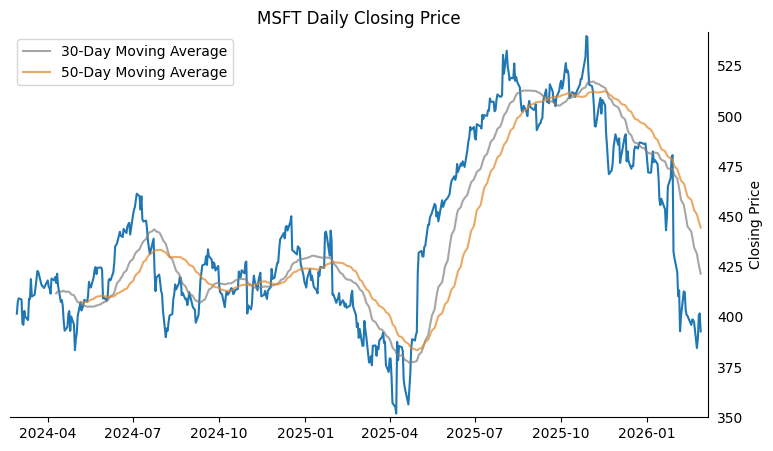

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

#main price plot
sns.lineplot(data=df, x='date', y='MSFT_close', ax=ax)

#add 30-day moving average. This will be it's own line plot that we'll plot on the same axis
sns.lineplot(data=df, x='date', y='30_ma', label='30-Day Moving Average', color='grey', alpha=0.7, ax=ax)

#add 50-day moving average
sns.lineplot(data=df, x='date', y='50_ma', label='50-Day Moving Average', color='#e18727ff', alpha=0.7, ax=ax)

#update axis labels and title - remove x-label, clean up y-label and add title
ax.set(xlabel='', ylabel='Closing Price', title='MSFT Daily Closing Price')

#move the y-axis to the right side, since the most recent data is what we care about
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')

#close margins to remove space between axes and the data
ax.margins(x=0.01, y=0.01)

#remove spine from left and top of chart to give more open look
sns.despine(top=True, left=True, right=False);

## 2. The Central Limit Theorem

Now that we have a feel for the data and some key descriptive statistics, we can move toward **statistical inference** — drawing conclusions about a population based on samples.

Inference relies on the **Central Limit Theorem (CLT)**, which states that the sampling distribution of a statistic (such as the mean) will be approximately normally distributed when the sample size is sufficiently large — regardless of the shape of the underlying population distribution.

To demonstrate this, we'll work with a "population" we know has a highly non-normal distribution: the S&P 500 Index (`SPY`) price over the past five years.


In [17]:
df=get_tickers(tickers=['SPY'], period='5y')
df.head()

[*********************100%***********************]  1 of 1 completed


,date,SPY_close,SPY_return
0,2021-03-01,363.663696,0.000000
1,2021-03-02,360.825958,-0.780319
2,2021-03-03,356.046539,-1.324577
3,2021-03-04,351.640594,-1.237463
4,2021-03-05,358.109528,1.839643


### 2.1 A Non-Normal Population

Let's visualize the price distribution and note the population mean. We expect to see a skewed, non-normal shape.


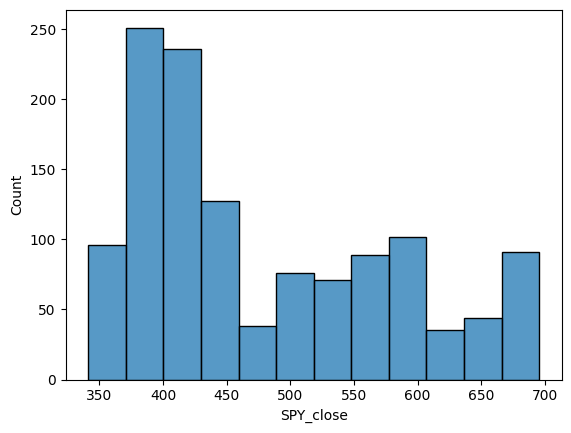

In [19]:
sns.histplot(data=df,x='SPY_close');

In [20]:
mean_price=np.mean(df.SPY_close)
print(f'Mean Price: ${mean_price:,.2f}') 

Mean Price: $480.10


Clearly non-normal. The CLT tells us that even though the population is skewed, the **distribution of sample means** will approach normality as the sample size increases. Let's verify this by drawing 1,000 random samples at three different sample sizes and plotting the resulting distributions.


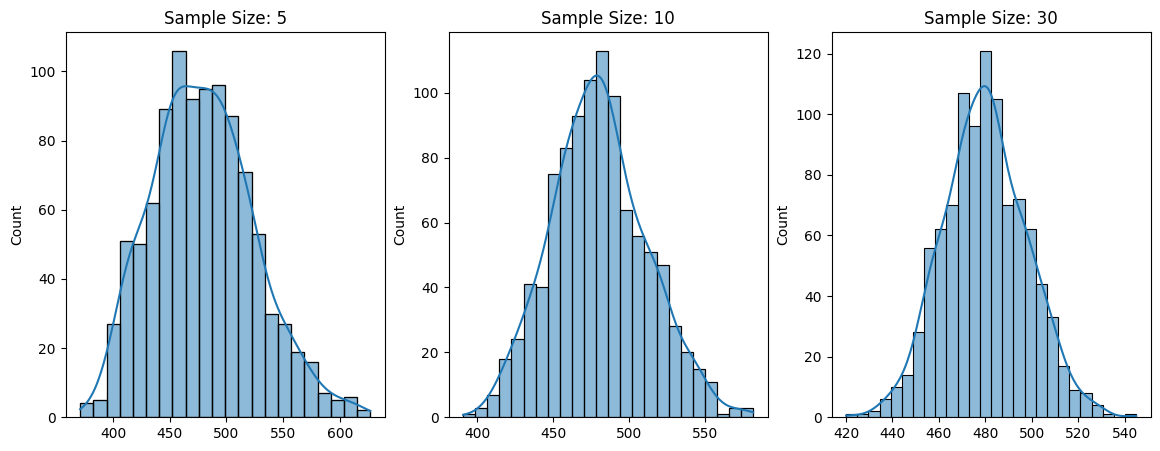

In [21]:
#we'll take samples of 10, 25, and 50 days, and do 1,000 of each. We'll store the sample means in a dictionary, using the sample size as the key
d_samples={5:[], 10:[], 30:[]}

for s in d_samples:
    for i in range(1000):
        sample = np.random.choice(df.SPY_close, size=s, replace=False)
        sample_mean=np.mean(sample)
        d_samples[s].append(sample_mean)

#now we'll plot each of the sampling distributions in a histogram
fig, ax = plt.subplots(1,3, figsize=(14, 5))

for a, s in zip(ax,d_samples):
    sns.histplot(x=d_samples[s], kde=True, ax=a)
    a.set(title='Sample Size: '+str(s));

Even at a sample size of 10, the distribution of sample means is beginning to look normal. By 30, it is nearly perfect — a compelling demonstration of the CLT in action.

### 2.2 Confidence Intervals

Since sample means are normally distributed, we can construct **confidence intervals** — ranges of values likely to contain the true population parameter. A 95% confidence interval means that if we repeated this process many times, 95% of our intervals would capture the true mean.

Let's write a function to compute confidence intervals using the **t-distribution**, then draw 10 samples and plot their intervals against the known population mean. Don't worry too much about understanding the math in the function. The important concept is understanding how to interpret a confidence interval.


In [22]:
def conf_int_t(data, conf_level):
    n=len(data)
    df=n-1
    sample_std=np.std(data, ddof=1)
    sample_mean=np.mean(data)
    #step 1 - find std error of sample dist
    sem=sample_std/np.sqrt(n)
    #step 2 - find critical t-value
    alpha=1-conf_level
    q=1-(alpha/2)
    t=stats.t.ppf(q, df)
    #step 3 - find margin of error
    me=sem*t
    #step 4 - contruct interval
    ci=(sample_mean-me, sample_mean+me)
    return ci

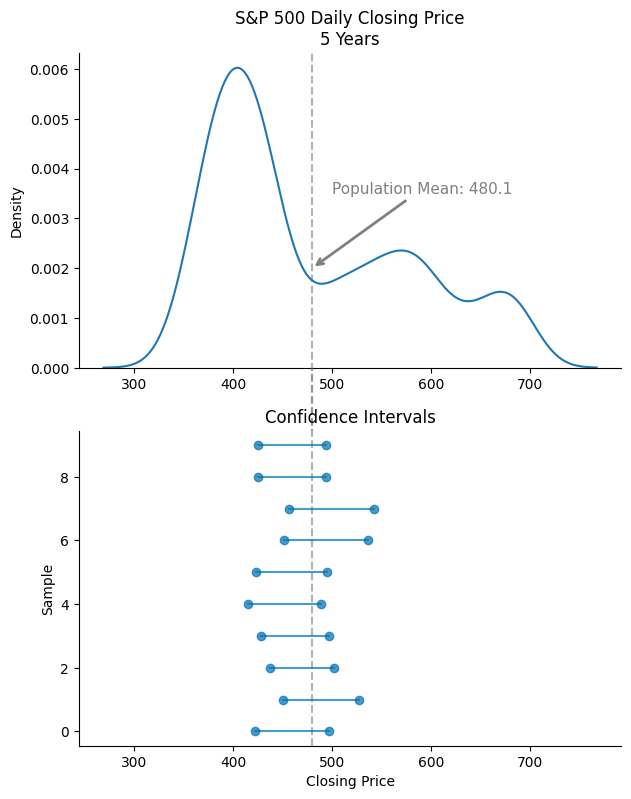

In [23]:
fig, ax = plt.subplots(2,1, figsize=(7, 9), sharex=True)
sns.despine(right=True, top=True)

#popultaion plot will be on top - showing the distribution of all prices
sns.kdeplot(x=df.SPY_close, ax=ax[0]).set_title('S&P 500 Daily Closing Price\n5 Years');
ax[0].xaxis.set_tick_params(which='both', labelbottom=True)

#draw line across entire figure at the population mean
pop_mean=np.mean(df.SPY_close)
ax[0].axvline(x=pop_mean, ymin=-1.2,ymax=1, zorder=0, clip_on=False, linestyle='--', color='grey', alpha=0.6)
ax[1].axvline(x=pop_mean, ymin=0,ymax=1.2, zorder=0, clip_on=False, linestyle='--', color='grey', alpha=0.6)

#confidence intervals - let's take 10 samples of 30 days each and use our confidence interval function to get the lower and upper limits
for i in range(0,10):
    sample = np.random.choice(df.SPY_close, size=s, replace=False)
    ci=conf_int_t(data=sample, conf_level=0.95) ### PLUG IN ANY CONFIDENCE LEVEL YOU WANT HERE ###
    ax[1].plot([ci[0], ci[1]], [i, i], '-o', color='#0072b5ff', alpha=0.7)
ax[1].set(ylabel='Sample', xlabel='Closing Price', title='Confidence Intervals')
ax[0].annotate('Population Mean: '+str(round(pop_mean,2)), #add what we want 
            xy=(pop_mean, 0.002), xytext=(500, 0.0035), # xy: The end point of the arrow (arrowhead position); xytext: The start point of the arrow (arrow tail position)
            arrowprops=dict(arrowstyle='->', color='grey', lw=2), #lw: linewidth in pixels
            fontsize=11, color='grey');

Did every interval capture the true population mean? With a 95% confidence level, we'd expect roughly 9 out of 10 to succeed on average. Try adjusting the confidence level in the cell above to explore the trade-off between confidence and interval width.


## 3. Correlation and Linear Regression

### 3.1 Comparing Two Stocks

When building a diversified portfolio, we want securities with **low correlation** — assets that don't move in lockstep. If two stocks are highly correlated, holding both provides little diversification benefit.

Let's compare Microsoft with Oracle (`ORCL`), another major player in enterprise technology and AI infrastructure.


In [25]:
tickers=['MSFT', 'ORCL']

df=get_tickers(tickers=tickers, period='2y')
df.head()

[*********************100%***********************]  2 of 2 completed


,date,MSFT_close,MSFT_return,ORCL_close,ORCL_return
0,2024-02-28,401.556610,0.000000,109.378365,0.000000
1,2024-02-29,407.387146,1.451984,109.378365,0.000000
2,2024-03-01,409.219025,0.449665,111.435089,1.880376
3,2024-03-04,408.647766,-0.139597,111.709312,0.246083
4,2024-03-05,396.563263,-2.957193,108.653618,-2.735398


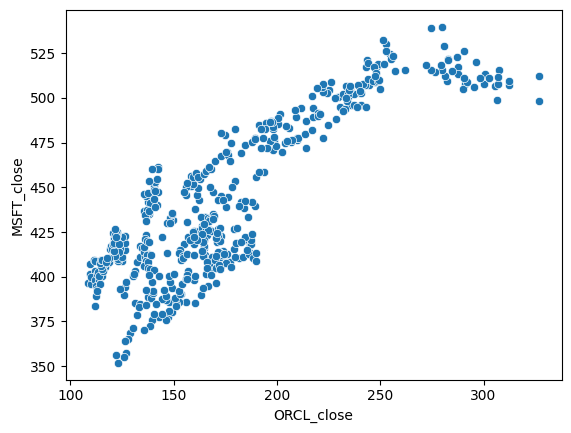

In [26]:
sns.scatterplot(data=df,x='ORCL_close', y='MSFT_close');

There appears to be a strong positive relationship between these two stocks. Let's quantify it by fitting a linear regression model using `scipy.stats.linregress()`, which returns:

- **Slope** and **intercept** of the best-fit line
- **Correlation coefficient (r)** — the strength and direction of the linear relationship
- **p-value** — the statistical significance of the relationship
- **Standard error** of the slope estimate


In [27]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df.MSFT_close, df.ORCL_close)

#let's print the linear formula and r value
print(f'Correlation (r): {round(r_value,2)}')
print(f'y={round(intercept,2)}+{round(slope,2)}x')

Correlation (r): 0.85
y=-252.06+0.97x


### 3.2 Visualizing the Linear Model

This correlation indicates a strong positive relationship — these two stocks move together closely, which is evidence against holding both for diversification purposes.

Let's create a polished regression plot using Seaborn's `.regplot()`, which overlays a line of best fit on a scatter plot. The `ci` parameter adds **confidence bands** around the line to reflect the uncertainty in the model's estimates. Try changing the confidence level to see how it impacts the visualization


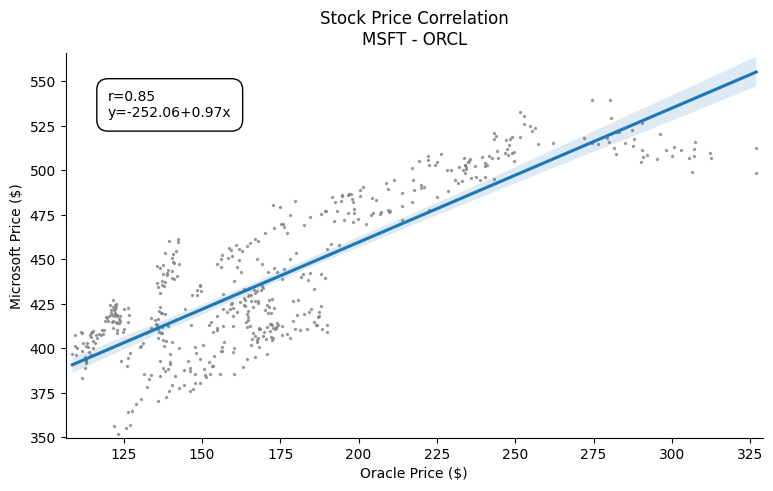

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))

#regplot
sns.regplot(data=df,x='ORCL_close', y='MSFT_close', ci=99, ### this is where we set the confidence interval
            scatter_kws={'s':2,'alpha':0.7, 'color':'grey'}, 
            line_kws={},
            ax=ax)

#axis labels and title
linear_model=f'y={round(intercept,2)}+{round(slope,2)}x'
ax.set(xlabel='Oracle Price ($)', ylabel='Microsoft Price ($)', title='Stock Price Correlation\nMSFT - ORCL')

#annotate with correlation coefficient and linear model
linear_model=f'y={round(intercept,2)}+{round(slope,2)}x'
ax.text(120,530, f'r={round(r_value,2)}\n{linear_model}', #x-coordinate, y-coordinate, text
       bbox={'edgecolor':'black', 
             'facecolor':'white', 
             'pad':0.8,
             'boxstyle':'round'})

#close margins to remove space between axes and the data
ax.margins(x=0.01, y=0.01)

#despine plot
sns.despine(top=True, right=True);

## 4. Group Comparisons with Confidence Intervals

### 4.1 The Magnificent Seven

So far we've estimated parameters for simple linear models - the slope and intercept. We can also estimate **population means** based on a sample data set.

Let's look at the mean daily returns for the "Magnificent Seven" — the seven largest U.S. companies by market capitalization: Microsoft, NVIDIA, Apple, Google, Meta, Tesla, and Amazon. We'll use the last three months of trading data as our "sample".


In [30]:
mag7=['MSFT', 'NVDA', 'AAPL', 'GOOG', 'META', 'TSLA', 'AMZN']

df=get_tickers(tickers=mag7, period='3mo')
df.head()

[*********************100%***********************]  7 of 7 completed


,date,MSFT_close,MSFT_return,NVDA_close,NVDA_return,AAPL_close,AAPL_return,GOOG_close,GOOG_return,META_close,META_return,TSLA_close,TSLA_return,AMZN_close,AMZN_return
0,2025-11-28,490.889587,0.000000,176.990143,0.000000,278.589325,0.000000,319.911285,0.000000,647.421997,0.000000,430.170013,0.000000,233.220001,0.000000
1,2025-12-01,485.631561,-1.071122,179.909988,1.649722,282.835358,1.524119,314.914520,-1.561922,640.347717,-1.092684,430.140015,-0.006974,233.880005,0.282996
2,2025-12-02,488.884155,0.669766,181.449905,0.855937,285.922455,1.091482,315.813934,0.285606,646.572632,0.972115,429.239990,-0.209240,234.419998,0.230885
3,2025-12-03,476.642090,-2.504083,179.580002,-1.030534,283.884369,-0.712811,320.410950,1.455609,639.078735,-1.159019,446.739990,4.076973,232.380005,-0.870230
4,2025-12-04,479.744995,0.650993,183.380005,2.116050,280.437592,-1.214148,318.182434,-0.695518,660.990967,3.428722,454.529999,1.743746,229.110001,-1.407180


### 4.2 Reshaping the Data

Our current DataFrame has one row per date with columns for each ticker. To create a grouped chart, we need to **reshape it into long format**, where each row represents a single observation for one ticker on one day. This structure is sometimes called "tidy" data.


In [31]:
df_bar=pd.DataFrame(columns=['date', 'ticker', 'return'])

for index, row in df.iterrows():
    for t in mag7:
        df_bar.loc[len(df_bar)]=[row.date, t, row[t+'_return']]
df_bar

,date,ticker,return
0,2025-11-28,MSFT,0.000000
1,2025-11-28,NVDA,0.000000
2,2025-11-28,AAPL,0.000000
3,2025-11-28,GOOG,0.000000
4,2025-11-28,META,0.000000
...,...,...,...
429,2026-02-27,AAPL,-3.213050
430,2026-02-27,GOOG,1.393456
431,2026-02-27,META,-1.343970
432,2026-02-27,TSLA,-1.485628


### 4.3 Bar Plot with Confidence Intervals

A bar plot with error bars is an intuitive way to compare means across groups. Seaborn's `barplot()` automatically computes and displays confidence intervals. Let's start with a quick preview before building a polished version.


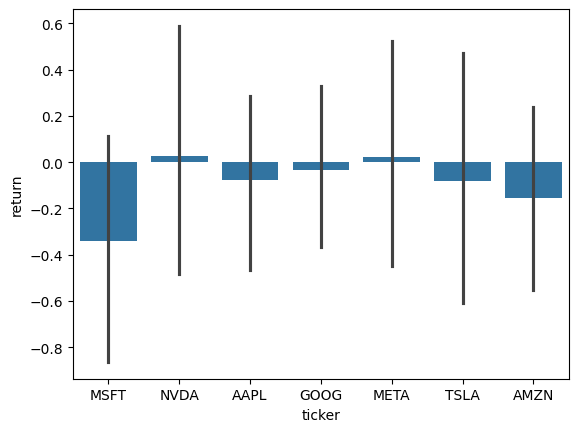

In [32]:
sns.barplot(data=df_bar, x='ticker', y='return');

Now let's build a polished version that compares **95% and 90% confidence intervals** side by side. A narrower interval (90%) is easier to distinguish from zero, but carries a greater risk of missing the true mean. Placing both in a single figure makes the trade-off immediately visible.


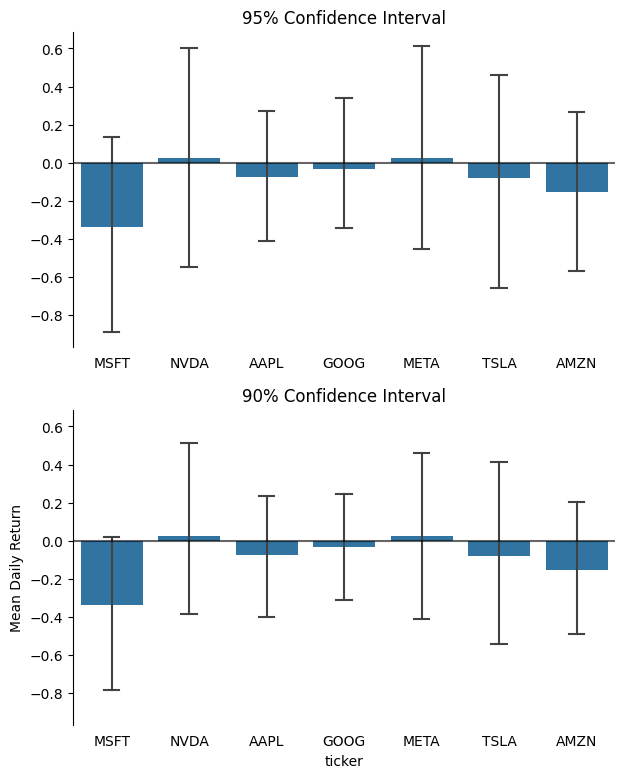

In [33]:
fig, ax = plt.subplots(2,1, figsize=(7, 9), sharex=True, sharey=True)
sns.despine(right=True, top=True, bottom=True)

#95% ci
sns.barplot(data=df_bar, y='return', x='ticker',errorbar=('ci', 95), capsize=0.2, err_kws={'linewidth': 1.5}, ax=ax[0])
ax[0].set(ylabel='',title='95% Confidence Interval')
#draw a line at 0 to identify stocks with average positive vs negative returns
ax[0].axhline(y=0, color='black', linestyle='-', alpha=0.6)
#remove ticks from x axis
ax[0].tick_params(bottom=False, labelbottom=True) 

#90% ci
sns.barplot(data=df_bar, y='return', x='ticker',errorbar=('ci', 90), capsize=0.2, err_kws={'linewidth': 1.5}, ax=ax[1])
ax[1].set(ylabel='Mean Daily Return',title='90% Confidence Interval')
#draw a line at 0 to identify stocks with average positive vs negative point estimates
ax[1].axhline(y=0, color='black', linestyle='-', alpha=0.6)
#remove ticks from x axis
ax[1].tick_params(bottom=False) ;

### 4.4 Point Plot with Confidence Intervals

Bar plots are familiar, but **point plots** are often preferred in statistical contexts — they draw less visual attention to bar heights and keep the focus on the estimated mean and its uncertainty. Let's recreate the same comparison using Seaborn's `pointplot()`, and flip the axes for a cleaner horizontal layout.


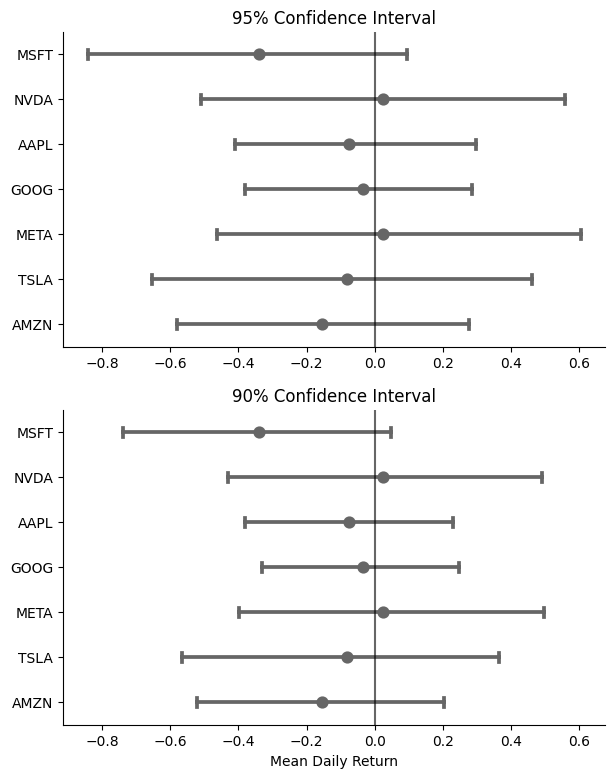

In [30]:
fig, ax = plt.subplots(2,1, figsize=(7, 9), sharex=True, sharey=True)
sns.despine(right=True, top=True)

#95% ci
sns.pointplot(data=df_bar,y='ticker', x='return', linestyle='none', capsize=.2,
             errorbar=("ci", 95), color='0.4', ax=ax[0])
ax[0].set(ylabel='', xlabel='', title='95% Confidence Interval')
ax[0].tick_params(labelbottom=True)
#draw a line at 0 to identify stocks with average positive vs negative point estimates
ax[0].axvline(x=0, color='black', linestyle='-', alpha=0.6)

#90% ci
sns.pointplot(data=df_bar,y='ticker', x='return', linestyle='none', capsize=.2,
             errorbar=("ci", 90), color='0.4', ax=ax[1])
ax[1].set(ylabel='', xlabel='Mean Daily Return', title='90% Confidence Interval')
#draw a line at 0 to identify stocks with average positive vs negative returns
ax[1].axvline(x=0, color='black', linestyle='-', alpha=0.6);

---

## Workshop Summary

In this workshop, you built a working foundation in descriptive statistics and statistical inference using real financial data. Here's what you covered:

| Topic | Key Concepts |
|---|---|
| **Exploratory Data Analysis** | Histograms, box plots, line plots, descriptive statistics (mean, median, standard deviation) |
| **Data Wrangling** | Cleaning multi-index DataFrames, computing derived columns, reshaping to long format |
| **Visualization** | `plt.subplots()` figure/axis pattern, moving averages, plot styling with Seaborn |
| **Central Limit Theorem** | Sampling distributions, effect of sample size, normality of sample statistics |
| **Confidence Intervals** | t-distribution, margin of error, interpreting coverage probability |
| **Correlation & Regression** | Pearson's r, `scipy.stats.linregress()`, regression plots with confidence bands |
| **Group Comparisons** | Bar plots and point plots with bootstrapped confidence intervals |

---

## Ideas for Further Practice

**Extend the analysis**
- Swap in different tickers and time periods. How do the results change for a more volatile stock like `TSLA` versus a stable one like `JNJ`?
- Add a third stock to the correlation analysis and build a **correlation matrix** using `df.corr()` and Seaborn's `heatmap()`.
- Compute **rolling volatility** (a rolling standard deviation of returns) and plot it alongside the price to see how risk changes over time.

**Go deeper on inference**
- Explore the effect of sample size on confidence interval width by systematically varying `n` and plotting the results.
- Investigate what happens to the CLT demonstration when the sample is drawn *with* replacement versus *without* replacement.

**Improve the visualizations**
- Apply a consistent Seaborn theme (`sns.set_theme()`) across the entire notebook for a unified look.
- Annotate the price line plot with labels for notable events (e.g., earnings dates or major market moves).
- Experiment with Seaborn's `FacetGrid` to create small multiples across all seven Magnificent Seven stocks.
